In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
from coffea import util
from coffea.processor import accumulate
import os
import re
import pandas as pd
import hist
import matplotlib as mpl
import mplhep
import sys
import hist
import hist.intervals

sys.path.append("../analysisTools/")
import plotTools as ptools
import utils

In [2]:
f_sig = "../coffea/AllInOne_2022/Resolution_DSCBsigma.coffea"

sig_histo = util.load(f_sig) [0]


Hist(
  Variable(array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12.,
       13., 14., 15., 16., 17., 18., 19., 20., 21., 22., 23., 24., 25.]), name='Gen_pt'),
  Regular(200, -1, 1, name='Res_LPT'),
  storage=Weight()) # Sum: WeightedSum(value=158, variance=158) (WeightedSum(value=166, variance=166) with flow)


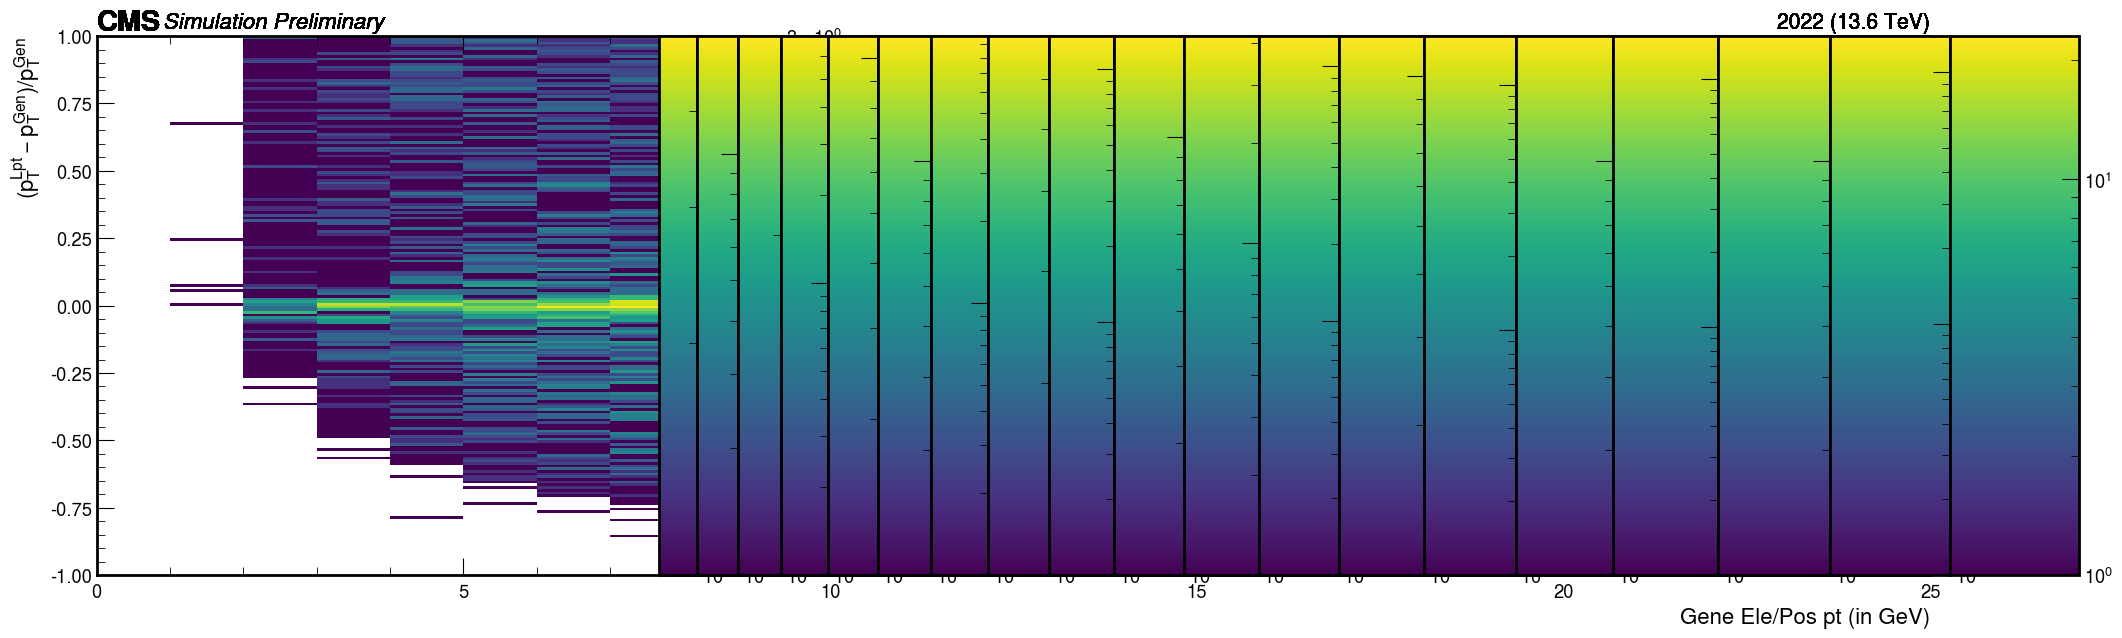

In [13]:
fig, ax = plt.subplots(figsize=(7,7))


# Plot settings
plot_dict = {
    'variable':'res_LPT_gen_ptbin',
    'cut': 'cut1',
    'year': 2022
}


style_2d_dict = {
    'fig': fig,
    'ax': ax,
    'xrebin': None,
    'yrebin': None,
    'xlim': None,     # if None, the default will show up; otherwise give as a list, i.e. [0, 10]  
    'ylim': None,     # if None, the default will show up; otherwise give as a list, i.e. [0, 10]
    'doLogy': False, 
    'doLogx': False,
    'doLogz': True,
    'xlabel': "Gene Ele/Pos pt (in GeV)",   # if None, the default will show up; otherwise give as a string, i.e. 'Electron dxy'
    'ylabel': r'$(p_{T}^{\mathrm{Lpt}}-p_{T}^{\mathrm{Gen}})/p_{T}^{\mathrm{Gen}}$',   # if None, the default will show up; otherwise give as a string, i.e. 'Efficiency'
    'zlabel': None,   
    'flow': None,     # overflow
    'doSave': False,
    'outDir': './plots/signal_2018',
    'outName': f'ptvslxy.png'
}

#signal points
samples = {
    10: 
    {
        0.1: [10],
        0.2: [1,100],
    },
    20: 
    {
        
        0.2: [1, 100],
    },
    30: 
    {
        0.1: [10],
        0.2: [1,100]
    },
    40: 
    {
        0.2: [1, 100],
    },
    50:
    {
        0.1: [10],
        0.2: [1,100],
    },
    60:
    {
         0.2: [1,100],
    },
    70:
    {
         0.2: [1,100],
    },
    80:
    {
         0.2: [1,100],
    }
 
}


h_list_lpt=[]
h_sum_lpt = None

for m1,deltas in samples.items():
    for delta, ctaus in deltas.items():
        for ctau in ctaus:
            h_lpt = ptools.plot_signal_2D(sig_histo, m1, delta, ctau, plot_dict, style_2d_dict)
            h_list_lpt.append(h_lpt)            
            if h_sum_lpt is None:
                h_sum_lpt = h_lpt.copy()
                print (h_sum_lpt)
            else:
                h_sum_lpt += h_lpt



In [4]:
#I need: pTbin index, ydata = COUNTS, xdata = BIN CENTERS, YERR:

first_data = []

totalnumber_genpt_bins = len(h_sum_lpt.axes[0].edges)-1

for genpt_bin_index in range(totalnumber_genpt_bins):
    ptbin_index = genpt_bin_index
    pt_value_range = (genpt_bin_index, genpt_bin_index+1)
    
    counts = h_sum_lpt[genpt_bin_index, :].values() 
    
    bin_edges = h_sum_lpt[genpt_bin_index, :].axes[0].edges 
    bincenters = (bin_edges[1:]+bin_edges[:-1])/2 
    
    variances = h_sum_lpt[genpt_bin_index, :].variances() 
    yerr = np.sqrt(variances)

    first_data.append({"ptbin_index": ptbin_index, "pt_value_range":pt_value_range, "xdata": bincenters, "ydata": counts, "yerror": yerr} )
   
# first_data

In [5]:
for data in first_data:
    x=data["xdata"]
    y=data["ydata"]
    sig = data["yerror"]
    index = data["ptbin_index"]

    mask = y>0 
    data["y_new_data"] = y[mask]
    data["x_new_data"] = x[mask]
    data["yerr_new_data"] = sig[mask]
    
# first_data

In [6]:
first_data = [data for data in first_data
              if (len(data["y_new_data"]) )> 0]
# first_data

In [7]:
n_parameters = 7
first_data = [data for data in first_data
              if (len(data["y_new_data"]) )> n_parameters]
# first_data

In [8]:
#1. Define your model

def double_cb(x,u,sig, nl, a_l, nr, a_r,N):
    t=(x-u)/(sig)
    al = abs(a_l)
    ar = abs(a_r)

    left_tail = t < -al
    core = (t>-al) & (t<ar)
    right_tail = t > ar

    y=np.empty_like(t)

    y[core] = np.exp(-0.5*t[core]*t[core])

    A_L = (nl / al)**nl * np.exp(-0.5 * al**2)
    B_L = (nl / al) - al
    y[left_tail] = A_L / (B_L - t[left_tail])**nl

    A_R = (nr / ar)**nr * np.exp(-0.5 * ar**2)
    B_R = (nr / ar) - ar
    y[right_tail] = A_R / (B_R + t[right_tail])**nr

    return N*y


/uscms/home/reshmar/nobackup/miniforge3/envs/coffea/lib/python3.8/site-packages/mplhep/plot.py:494: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  _e = ax.errorbar(
/uscms/home/reshmar/nobackup/miniforge3/envs/coffea/lib/python3.8/site-packages/mplhep/plot.py:494: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  _e = ax.errorbar(
/uscms/home/reshmar/nobackup/miniforge3/envs/coffea/lib/python3.8/site-packages/mplhep/plot.py:494: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  _e = ax.errorbar(
/uscms/home/reshmar/nobackup/miniforge3/envs/coffea/lib/python3.8/site-packages/mplhep/plot.py:494: UserWarning: marker is redundantly defined by the 'marker' keyw

[{'pT bin index': 2,
  'pt_value_range': (2, 3),
  'fit_mean': 0.0006174340457586643,
  'fit_mean_unc': 0.000570202883936611,
  'fit_sigma': 0.015813298858769143,
  'fit_sigma_unc': 0.0006186284089112308,
  'chi2/ndof': 1.7383773189751757},
 {'pT bin index': 3,
  'pt_value_range': (3, 4),
  'fit_mean': -0.0005995201211783426,
  'fit_mean_unc': 0.0005983777440745001,
  'fit_sigma': 0.018891825366270026,
  'fit_sigma_unc': 0.0005972127001451253,
  'chi2/ndof': 2.0484767587150534},
 {'pT bin index': 4,
  'pt_value_range': (4, 5),
  'fit_mean': -3.5655757344662965e-05,
  'fit_mean_unc': 0.0005565332380334878,
  'fit_sigma': 0.018428990903402758,
  'fit_sigma_unc': 0.0006749714602114475,
  'chi2/ndof': 2.4167389147987586},
 {'pT bin index': 5,
  'pt_value_range': (5, 6),
  'fit_mean': 0.0012370916195650287,
  'fit_mean_unc': 0.0006329738438875354,
  'fit_sigma': 0.018097420885787467,
  'fit_sigma_unc': 0.0007636389332842629,
  'chi2/ndof': 3.7814688480141947},
 {'pT bin index': 6,
  'pt_val

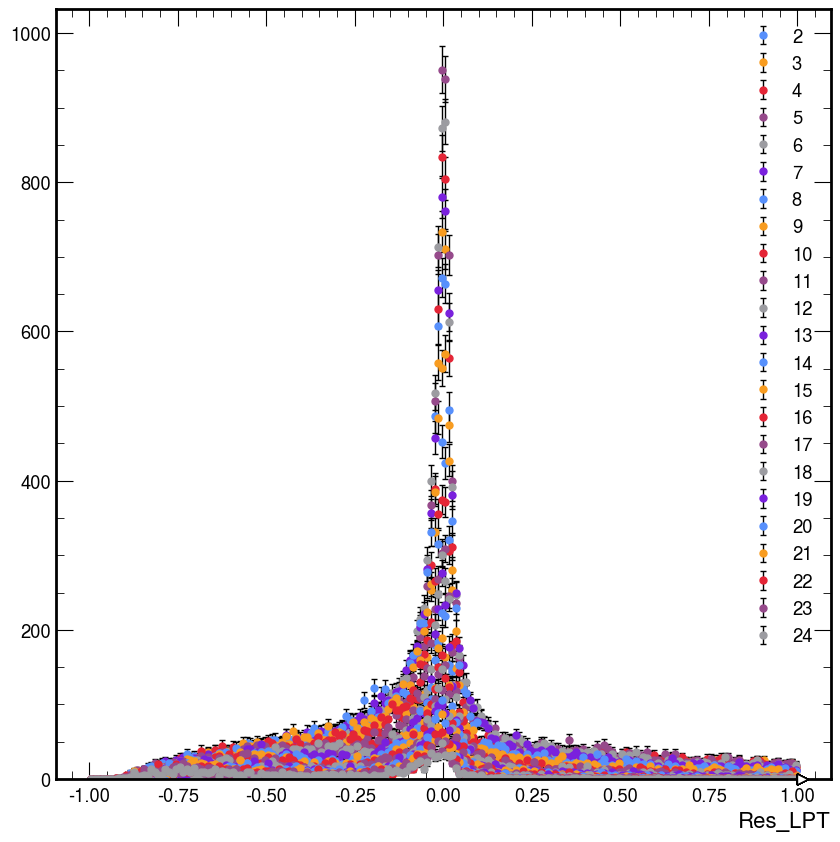

In [9]:
from scipy.optimize import curve_fit

fit_data=[]

for data in first_data:
    mplhep.histplot( h_sum_lpt[data["ptbin_index"], :],histtype='errorbar', yerr=True,  fmt='o',capsize=2, ecolor='black', label=data["ptbin_index"])
    plt.legend()
    # initial_guess = [0.0002642, 0.02177, 1, 0.2, 1, 0.2,data["y_new_data"].max()] #[mean, sigma, nl, al, nr, ar, N]
    # initial_guess = [0.005, 0.02177, 1, 0.2, 1, 0.2,data["y_new_data"].max()] #[mean, sigma, nl, al, nr, ar, N]

    mean0 = np.average(data["x_new_data"], weights=data["y_new_data"])
    sigma0 = np.sqrt(np.average((data["x_new_data"]-mean0)**2, weights=data["y_new_data"]))

   # [mean, sigma, nl, al, nr, ar, N]:  [0.0002642, 0.02177, 1, 0.2, 1, 0.2,data["y_new_data"].max()]
    initial_guess = [mean0, sigma0, 1, 0.2, 1, 0.2, data["y_new_data"].max()]

    lower = [x.min(), 1e-5, 0.5, 0.05, 0.1, 0.05, 0]
    upper = [x.max(), (x.max()-x.min()), 2, 1, 5, 2, 5*data["y_new_data"].max()]


    popt, pcov = curve_fit(double_cb, data["x_new_data"], data["y_new_data"], p0=initial_guess, sigma=data["yerr_new_data"], absolute_sigma=True, bounds=(lower, upper), maxfev=20000)
    perr = np.sqrt(np.diag(pcov))

    yp = double_cb(data["x_new_data"], *popt)

    eq = (data["y_new_data"]-yp)/(data["yerr_new_data"])
    chi2 = np.sum(eq**2)

    ndof = len(data["y_new_data"]) - len(popt)

    chi2ndof = chi2/ndof

    

    fit_mean = f"{popt[0]:.5f} ± {perr[0]:.5f}"
    fit_sigma = f"{popt[1]:.5f} ± {perr[1]:.5f}"

    fit_data.append({"pT bin index":data["ptbin_index"],"pt_value_range":data["pt_value_range"], "fit_mean": popt[0], "fit_mean_unc": perr[0], "fit_sigma":popt[1],"fit_sigma_unc":perr[1], "chi2/ndof":chi2ndof})




fit_data  


In [10]:
plot_pars = []
for i in fit_data:
    pt_low, pt_high = i["pt_value_range"]
    pt_center = (pt_low + pt_high) / 2
    plot_pars.append({"Genpt":pt_center, "DSCB sigmafit": round(i["fit_sigma"],5), "sigma_unc":round(i["fit_sigma_unc"],5)})
    
plot_pars

[{'Genpt': 2.5, 'DSCB sigmafit': 0.01581, 'sigma_unc': 0.00062},
 {'Genpt': 3.5, 'DSCB sigmafit': 0.01889, 'sigma_unc': 0.0006},
 {'Genpt': 4.5, 'DSCB sigmafit': 0.01843, 'sigma_unc': 0.00067},
 {'Genpt': 5.5, 'DSCB sigmafit': 0.0181, 'sigma_unc': 0.00076},
 {'Genpt': 6.5, 'DSCB sigmafit': 0.01835, 'sigma_unc': 0.00101},
 {'Genpt': 7.5, 'DSCB sigmafit': 0.01882, 'sigma_unc': 0.00129},
 {'Genpt': 8.5, 'DSCB sigmafit': 0.02258, 'sigma_unc': 0.0014},
 {'Genpt': 9.5, 'DSCB sigmafit': 0.02105, 'sigma_unc': 0.00154},
 {'Genpt': 10.5, 'DSCB sigmafit': 0.01866, 'sigma_unc': 0.00218},
 {'Genpt': 11.5, 'DSCB sigmafit': 0.02192, 'sigma_unc': 0.00269},
 {'Genpt': 12.5, 'DSCB sigmafit': 0.02167, 'sigma_unc': 0.00173},
 {'Genpt': 13.5, 'DSCB sigmafit': 0.02371, 'sigma_unc': 0.00183},
 {'Genpt': 14.5, 'DSCB sigmafit': 0.02149, 'sigma_unc': 0.00222},
 {'Genpt': 15.5, 'DSCB sigmafit': 0.02433, 'sigma_unc': 0.00198},
 {'Genpt': 16.5, 'DSCB sigmafit': 0.02957, 'sigma_unc': 0.00194},
 {'Genpt': 17.5, 'DSC

[2.5, 3.5, 4.5, 5.5, 6.5, 7.5, 8.5, 9.5, 10.5, 11.5, 12.5, 13.5, 14.5, 15.5, 16.5, 17.5, 18.5, 19.5, 20.5, 21.5, 22.5, 23.5, 24.5]
[0.01581, 0.01889, 0.01843, 0.0181, 0.01835, 0.01882, 0.02258, 0.02105, 0.01866, 0.02192, 0.02167, 0.02371, 0.02149, 0.02433, 0.02957, 0.36003, 0.3774, 0.03338, 0.02225, 0.0293, 0.03227, 0.0349, 0.03265]


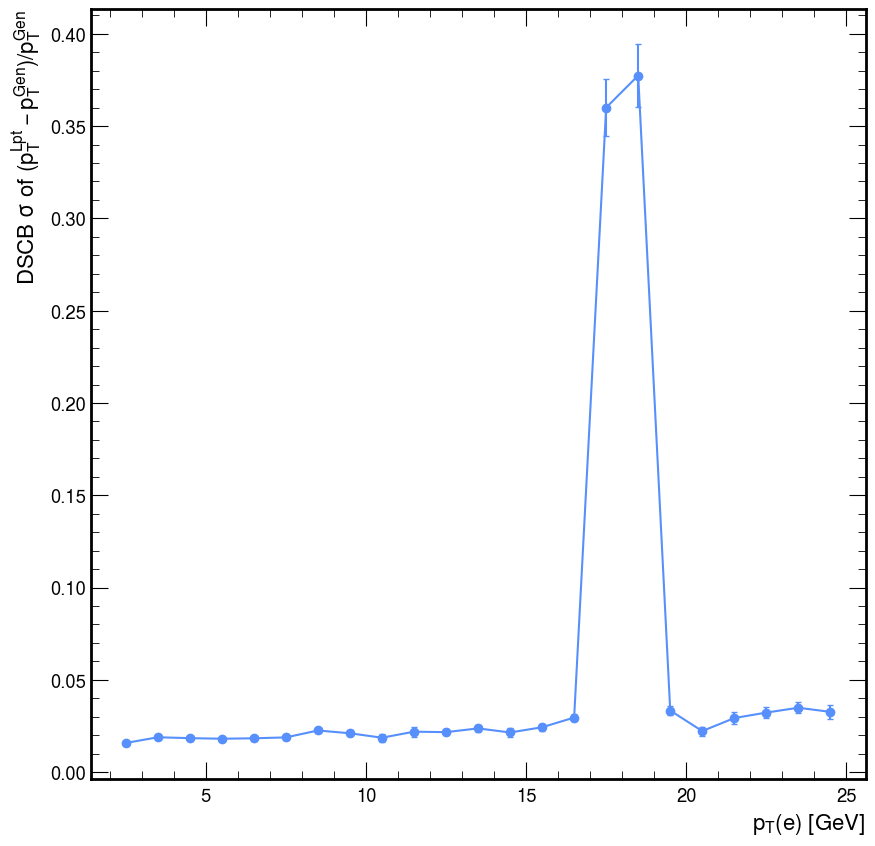

In [12]:
genpt = [p["Genpt"] for p in plot_pars]
print (genpt)
sigma = [p["DSCB sigmafit"] for p in plot_pars]
print (sigma)

sigma_unc = [p["sigma_unc"] for p in plot_pars]

plt.errorbar(
    genpt,
    sigma,
    yerr=sigma_unc,
    fmt="o-",
    capsize=2
)

plt.xlabel(r"$p_T(e)\ \mathrm{[GeV]}$")
plt.ylabel(
    r"DSCB $\sigma$ of $(p_{T}^{\mathrm{Lpt}}-p_{T}^{\mathrm{Gen}})/p_{T}^{\mathrm{Gen}}$"
)
plt.show()